In [22]:
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt

In [2]:
path = "./Dataset"
labels = ["Broccoli", "Carrot", "Cucumber", "Tomato"]
images, classes = [], []

In [3]:
def preprocess(path, size=(200,200)):
    img = load_img(path, target_size=size)
    img = img_to_array(img)
    img = tf.image.rgb_to_grayscale(img) / 255.0
    return img


In [4]:
for i, label in enumerate(labels):
    fd = os.path.join(path, label)
    for img_name in os.listdir(fd)[:500]:
        img_path = os.path.join(fd, img_name)
        images.append(preprocess(img_path))
        classes.append(i)

In [5]:
x = np.array(images)
y = tf.keras.utils.to_categorical(classes, num_classes=len(labels))

In [6]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation="relu", padding="same", input_shape=(200,200,1)),
    tf.keras.layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation="relu"),
    
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(labels), activation="softmax")
])

In [8]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 200, 200, 16)      160       
                                                                 
 conv2d_1 (Conv2D)           (None, 200, 200, 16)      2320      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 100, 100, 16)     0         
 )                                                               


                                                                 
 conv2d_2 (Conv2D)           (None, 100, 100, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 50, 50, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 80000)             0         
                                                                 
 dense (Dense)               (None, 16)                1280016   
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_1 (Dense)             (None, 4)                 68        
                                                                 
Total params: 1,287,204
Trainable params: 1,287,204
Non-trainable params: 0


In [9]:
cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=50, callbacks=cb)


Epoch 1/50
44/44 [==============================] - 39s 834ms/step - loss: 1.3162 - accuracy: 0.4000 - val_loss: 1.0556 - val_accuracy: 0.6000
Epoch 2/50
44/44 [==============================] - 38s 865ms/step - loss: 1.0264 - accuracy: 0.5550 - val_loss: 0.8265 - val_accuracy: 0.7167
Epoch 3/50
44/44 [==============================] - 40s 916ms/step - loss: 0.8789 - accuracy: 0.6264 - val_loss: 0.7468 - val_accuracy: 0.7467
Epoch 4/50
44/44 [==============================] - 40s 914ms/step - loss: 0.8367 - accuracy: 0.6379 - val_loss: 0.7118 - val_accuracy: 0.7767
Epoch 5/50
44/44 [==============================] - 41s 941ms/step - loss: 0.8128 - accuracy: 0.6500 - val_loss: 0.6814 - val_accuracy: 0.7700
Epoch 6/50
44/44 [==============================] - 42s 951ms/step - loss: 0.7087 - accuracy: 0.6886 - val_loss: 0.6179 - val_accuracy: 0.8100
Epoch 7/50
44/44 [==============================] - 42s 949ms/step - loss: 0.6293 - accuracy: 0.7271 - val_loss: 0.6495 - val_accuracy: 0.8167

In [10]:
# Results
model.evaluate(x_test, y_test)

10/10 [==============================] - 2s 165ms/step - loss: 0.6595 - accuracy: 0.8133


[0.6594569683074951, 0.8133333325386047]

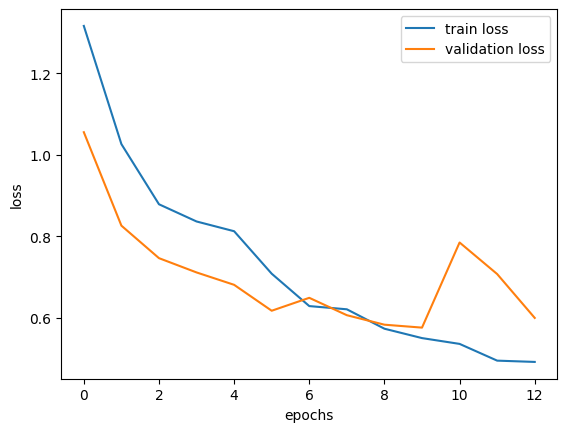

In [11]:
plt.plot(history.history["loss"], label = "train loss")
plt.plot(history.history["val_loss"], label = "validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

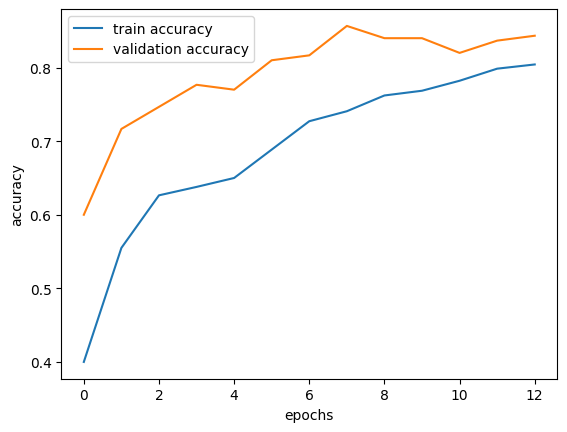

In [12]:
plt.plot(history.history["accuracy"], label = "train accuracy")
plt.plot(history.history["val_accuracy"], label = "validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [32]:
predi = model.predict(x_test)
r2_score = (y_test, predi)



10/10 [==============================] - 2s 180ms/step


In [ ]:
r2_score(y_test, model.predict(x_test))

In [ ]:
tp = "./Dataset/Cucumber/0004.jpg"  # ubah sesuai lokasi file
img = preprocess(tp)  # pake fungsi kamu
img = np.expand_dims(img, axis=0)  # tambahin batch dimension

pred = model.predict(img)
print("Prediction:", labels[np.argmax(pred)])
print("Confidence:", pred[0][np.argmax(pred)])


1/1 [==============================] - 0s 145ms/step
Prediction: Cucumber
Confidence: 0.99855465
